# Elfving 2010 growth demo

This notebook demonstrates a full workflow:

1. Reconstruct a young stand using NYSKOG.
2. Convert heights to DBH and apply sapling damage mortality.
3. Hand over the tree list to the Elfving (2010) growth model.
4. Update tree height (Söderberg 1992) and volume (Söderberg 1986) during growth.
5. Grow in 5-year steps, apply thinning at age 50, and plot results.

**Reproducibility:** fixed random seeds and deterministic NYSKOG settings.


## Notebook Objectives
- Show a complete growth workflow around Elfving (2010) stand development equations.
- Provide runnable, copy-safe snippets that work in the docs build environment.

## Prerequisites
- Python environment with `pyforestry` installed from this repository.
- Execute cells in order; random components should use fixed seeds where shown.

## Sources
- Elfving (2010) implementations in `pyforestry.sweden domain packages.elfving_2010` and related helpers.


In [1]:
import copy
import math
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pyforestry.base.helpers import CircularPlot, Stand, Tree
from pyforestry.base.helpers.primitives import Age, SiteBase
from pyforestry.base.helpers.tree_species import TreeSpecies
from pyforestry.sweden.adapters.elfving_1982 import (
    HuginMeanHeightModel,
    NfiRegion,
    NyskogReconstruction,
    RegenerationType,
    nyskog_indicators_from_site,
)
from pyforestry.sweden.adapters.elfving_2010 import Elfving2010Model
from pyforestry.sweden.mortality.naslund_1986 import (
    Naslund1986DamageModel,
    SaplingSpeciesGroup,
)
from pyforestry.sweden.systems.nystrom_soderberg_1987 import NystromSoderberg1987
from pyforestry.sweden.height.soderberg_1992 import soderberg_1992_height_tree_age_m
from pyforestry.sweden.site import Sweden, SwedishSite
from pyforestry.sweden.siteindex.sis.generated_site_category_trees import (
    predict_site_categories_county_tree,
)
from pyforestry.sweden.siteindex.sis.hagglund_lundmark_1977 import Hagglund_Lundmark_1977_SIS
from pyforestry.sweden.volume.soderberg_1986_form_height import soderberg_1986_volume_m3


class SwedishSiteDemo(SwedishSite):
    """Concrete wrapper for notebooks (implements SiteBase abstract method)."""

    def compute_attributes(self) -> None:
        SwedishSite.__post_init__(self)

    def __post_init__(self) -> None:
        SiteBase.__post_init__(self)


random.seed(42)
np.random.seed(42)


## 1. Define a Swedish site

In [2]:
site_index_pine_m = 20.0
site_index_spruce_m = 22.0
county = Sweden.County.KOPPARBERG_OVRIGA
site_category_species = "Pinus sylvestris"
requested_sis = site_index_pine_m

predicted_site_categories = predict_site_categories_county_tree(
    sis_hagglund_1979=requested_sis,
    species=site_category_species,
    Direktlan=county,
)

site = SwedishSiteDemo(
    latitude=60.5,
    longitude=15.0,
    altitude=150.0,
    field_layer=predicted_site_categories["field_layer"],
    bottom_layer=predicted_site_categories["bottom_layer"],
    soil_texture=predicted_site_categories["soil_texture"],
    soil_moisture=predicted_site_categories["soil_moisture"],
    soil_depth=predicted_site_categories["soil_depth"],
    soil_water=predicted_site_categories["soil_water"],
    ditched=predicted_site_categories["ditched"],
)

achieved_sis = Hagglund_Lundmark_1977_SIS(
    species=site_category_species,
    latitude=site.latitude,
    altitude=site.altitude or 0.0,
    soil_moisture=site.soil_moisture,
    ground_layer=site.bottom_layer or Sweden.BottomLayer.FRESH_MOSS,
    vegetation=site.field_layer,
    soil_texture=site.soil_texture or Sweden.SoilTextureTill.SANDY,
    climate_code=site.climate_zone or Sweden.ClimateZone.K1,
    lateral_water=site.soil_water or Sweden.SoilWater.SELDOM_NEVER,
    soil_depth=site.soil_depth or Sweden.SoilDepth.DEEP,
    incline_percent=site.incline_percent or 0.0,
    aspect=site.aspect or 0.0,
    nfi_adjustments=True,
    dlan=site.county or county,
    ditched=bool(site.ditched),
    peat=False,
    gotland=False,
    coast=(site.distance_to_coast or 9999.0) < 50.0,
    limes_norrlandicus=bool(site.n_of_limes_norrlandicus),
)

sis_closeness = {
    "requested_sis": requested_sis,
    "achieved_sis": float(achieved_sis),
    "sis_abs_error": abs(float(achieved_sis) - requested_sis),
    "sis_rel_error_pct": 100.0 * abs(float(achieved_sis) - requested_sis) / requested_sis,
}

display({"sis_closeness": sis_closeness, "predicted_site_categories": predicted_site_categories})
site

{'sis_closeness': {'requested_sis': 20.0,
  'achieved_sis': 20.698654683125625,
  'sis_abs_error': 0.6986546831256248,
  'sis_rel_error_pct': 3.493273415628124},
 'predicted_site_categories': {'field_layer': <SwedenFieldLayer.LICHEN_FREQUENT: Vegetation(code=17, swedish_name='Lavrik', english_name='Lichen, frequent occurrence', index=-0.5)>,
  'bottom_layer': <SwedenBottomLayer.BOGMOSS_TYPE: BottomLayerType(code=4, english_name='Bogmoss type (Sphagnum)', swedish_name='Vitmosstyp')>,
  'soil_texture': <SwedenSoilTextureTill.SANDY_MOIG: SoilTextureCategory(code=4, swedish_name='Sandig-moig morän', english_name='Sandy-silty till', short_name='Medium sand')>,
  'soil_moisture': <SwedenSoilMoisture.MESIC: SoilMoistureData(code=2, swedish_description='frisk', english_description='Mesic (subsoil water depth = 1-2 m)')>,
  'soil_depth': <SwedenSoilDepth.DEEP: SoilDepthCat(code=1, swedish_description='Mäktigt >70 cm. Inga synliga hällar', english_description='Deep >70cm. No visible stone outcro

SwedishSiteDemo(latitude=60.5, longitude=15.0, altitude=150.0, field_layer=<SwedenFieldLayer.LICHEN_FREQUENT: Vegetation(code=17, swedish_name='Lavrik', english_name='Lichen, frequent occurrence', index=-0.5)>, bottom_layer=<SwedenBottomLayer.BOGMOSS_TYPE: BottomLayerType(code=4, english_name='Bogmoss type (Sphagnum)', swedish_name='Vitmosstyp')>, soil_texture=<SwedenSoilTextureTill.SANDY_MOIG: SoilTextureCategory(code=4, swedish_name='Sandig-moig morän', english_name='Sandy-silty till', short_name='Medium sand')>, soil_moisture=<SwedenSoilMoisture.MESIC: SoilMoistureData(code=2, swedish_description='frisk', english_description='Mesic (subsoil water depth = 1-2 m)')>, soil_depth=<SwedenSoilDepth.DEEP: SoilDepthCat(code=1, swedish_description='Mäktigt >70 cm. Inga synliga hällar', english_description='Deep >70cm. No visible stone outcrops.')>, soil_water=<SwedenSoilWater.SHORTER_PERIODS: SoilWaterCat(code=2, swedish_description='kortare perioder', english_description='Shorter periods')>

## 2. Reconstruct a young stand (NYSKOG)

In [12]:
regen_type = RegenerationType.NATURAL
species_to_plant = TreeSpecies.Sweden.pinus_sylvestris
nfi_region = NfiRegion.REG3

age_years = 12.0

mean_height_main_m = HuginMeanHeightModel.mean_height(
    age_years=age_years,
    species=species_to_plant,
    site_index_pine_m=site_index_pine_m,
    site_index_spruce_m=site_index_spruce_m,
)

indicators = nyskog_indicators_from_site(
    field_layer=site.field_layer,
    soil_moisture=site.soil_moisture,
)

# NOTE: ASINW is typically derived from the published Elfving regeneration functions (Appendix 2).
asinw = 110.0
q = NyskogReconstruction.production_potential_q(asinw)
ln_q = math.log(q)
ln_si = math.log(site_index_pine_m)

under_dimension_prob = NyskogReconstruction.udim_probability(q)
height_indicator_dm = max(15.0, 10.0 * mean_height_main_m)

stem_total = NyskogReconstruction.total_stems(
    regeneration_type=regen_type,
    mean_height_main_m=mean_height_main_m,
    q=q,
    ln_q=ln_q,
    ln_si=ln_si,
    under_dimension_prob=under_dimension_prob,
    wet=indicators["wet"],
    dry=indicators["dry"],
    height_indicator_dm=height_indicator_dm,
    deterministic=True,
)

prop_conifer = NyskogReconstruction.proportion_conifer(
    regeneration_type=regen_type,
    q=q,
    ln_qind=ln_q,
    stem_total=stem_total,
    ln_si=ln_si,
    wet=indicators["wet"],
    dry=indicators["dry"],
    rich=indicators["rich"],
    poor=indicators["poor"],
    deterministic=True,
)

prop_dom_conifer = NyskogReconstruction.dominant_conifer_share(
    regeneration_type=regen_type,
    qind=q,
    ln_si=ln_si,
    wet=indicators["wet"],
    dry=indicators["dry"],
    rich=indicators["rich"],
    poor=indicators["poor"],
    hwod=indicators["hwod"],
    hwd=indicators["hwd"],
    shrubs=indicators["shrubs"],
    lichen=indicators["lichen"],
    deterministic=True,
)

stems = NyskogReconstruction.stems_per_species(
    regeneration_type=regen_type,
    species_to_plant=species_to_plant,
    stem_total=stem_total,
    prop_conifer=prop_conifer,
    prop_dom_conifer=prop_dom_conifer,
    site_index_m=site_index_pine_m,
    nfi_region=nfi_region,
)

stems

{'pine': 197.21557785033062,
 'spruce': 435.7513070153287,
 'contorta': 0.0,
 'larch': 0.0,
 'birch': 1159.603329004732,
 'other_broadleaf': 48.31680537519716}

In [13]:
def mean_height_secondary(species: TreeSpecies) -> float:
    site_index_m = (
        site_index_spruce_m
        if species
        in {
            TreeSpecies.Sweden.picea_abies,
            TreeSpecies.Sweden.picea_sitchensis,
            TreeSpecies.Sweden.picea_mariana,
        }
        else site_index_pine_m
    )

    return NyskogReconstruction.secondary_mean_height(
        regeneration_type=regen_type,
        secondary_species=species,
        site_index_m=site_index_m,
        mean_height_main_m=mean_height_main_m,
        herb=indicators["herb"],
        dry=indicators["dry"],
        wet=indicators["wet"],
        deterministic=True,
    )


species_map = {
    "pine": TreeSpecies.Sweden.pinus_sylvestris,
    "spruce": TreeSpecies.Sweden.picea_abies,
    "contorta": TreeSpecies.Sweden.pinus_contorta,
    "larch": TreeSpecies.Sweden.larix_sibirica,
    "birch": TreeSpecies.Sweden.betula_pendula,
    "other_broadleaf": TreeSpecies.Sweden.populus_tremula,
}

mean_heights = {
    "pine": mean_height_main_m,
    "spruce": mean_height_secondary(TreeSpecies.Sweden.picea_abies),
    "contorta": mean_height_secondary(TreeSpecies.Sweden.pinus_contorta),
    "larch": mean_height_secondary(TreeSpecies.Sweden.larix_sibirica),
    "birch": mean_height_secondary(TreeSpecies.Sweden.betula_pendula),
    "other_broadleaf": mean_height_secondary(TreeSpecies.Sweden.populus_tremula),
}

sample_n = 200

total_stems = sum(stems.values())
trees: list[Tree] = []

for label, stems_per_ha in stems.items():
    if stems_per_ha <= 0.0:
        continue
    share = stems_per_ha / total_stems
    n_trees = max(1, int(round(sample_n * share)))

    species = species_map[label]
    mean_height = mean_heights[label]
    cvh = NyskogReconstruction.height_variation(
        species=species,
        species_height_m=mean_height,
        q=q,
        ln_q=ln_q,
        self_rejuvenated=1,
        deterministic=True,
    )
    beta, shape = NyskogReconstruction.weibull_parameters(
        species=species,
        cvh=cvh,
        mean_height_m=mean_height,
    )

    heights = beta * np.random.weibull(shape, size=n_trees)
    weight = stems_per_ha / n_trees

    for height in heights:
        trees.append(
            Tree(
                species=species,
                height_m=float(height),
                weight_n=weight,
            )
        )

base_trees = copy.deepcopy(trees)
len(trees)

199

## 3. Convert heights to DBH and apply sapling damage

In [14]:
def stand_metrics(tree_list: list[Tree]) -> dict[str, float]:
    heights = np.array([t.height_m or 0.0 for t in tree_list])
    weights = np.array([t.weight_n or 0.0 for t in tree_list])
    total_weight = weights.sum()
    if total_weight <= 0.0:
        return {
            "mean_height_m": 0.0,
            "total_height_sqr_m2_per_100m2": 0.0,
            "broadleaf_height_sqr_share": 0.0,
            "h_max_m": 0.0,
        }
    mean_height = float((heights * weights).sum() / total_weight)

    height_sqr_sum = float(((heights**2) * weights).sum())
    total_height_sqr_m2_per_100m2 = height_sqr_sum * 0.01

    broadleaf_species = {
        TreeSpecies.Sweden.betula_pendula,
        TreeSpecies.Sweden.betula_pubescens,
        TreeSpecies.Sweden.populus_tremula,
    }
    broadleaf_mask = np.array([t.species in broadleaf_species for t in tree_list])
    broadleaf_sqr_sum = float(((heights**2) * weights * broadleaf_mask).sum())
    if height_sqr_sum > 0.0:
        broadleaf_share = broadleaf_sqr_sum / height_sqr_sum
    else:
        broadleaf_share = 0.0

    top_heights = sorted(heights, reverse=True)[:3]
    h_max_m = float(np.mean(top_heights)) if top_heights else 0.0

    return {
        "mean_height_m": mean_height,
        "total_height_sqr_m2_per_100m2": total_height_sqr_m2_per_100m2,
        "broadleaf_height_sqr_share": broadleaf_share,
        "h_max_m": h_max_m,
    }


def sapling_group(species: TreeSpecies) -> SaplingSpeciesGroup:
    if species in {
        TreeSpecies.Sweden.pinus_sylvestris,
        TreeSpecies.Sweden.larix_sibirica,
        TreeSpecies.Sweden.larix_decidua,
        TreeSpecies.Sweden.larix_europaea_x_leptolepis,
        TreeSpecies.Sweden.larix_sukaczewii,
    }:
        return SaplingSpeciesGroup.PINE
    if species == TreeSpecies.Sweden.pinus_contorta:
        return SaplingSpeciesGroup.CONTORTA
    if species == TreeSpecies.Sweden.picea_abies:
        return SaplingSpeciesGroup.SPRUCE
    if species in {
        TreeSpecies.Sweden.betula_pendula,
        TreeSpecies.Sweden.betula_pubescens,
    }:
        return SaplingSpeciesGroup.BIRCH
    if species in {
        TreeSpecies.Sweden.populus_tremula,
        TreeSpecies.Sweden.populus_tremula_x_tremuloides,
    }:
        return SaplingSpeciesGroup.ASPEN
    return SaplingSpeciesGroup.OTHER_BROADLEAF


def apply_dbh(tree_list: list[Tree]) -> None:
    metrics = stand_metrics(tree_list)
    if metrics["mean_height_m"] <= 0.0:
        return
    for tree in tree_list:
        if tree.height_m is None or tree.species is None:
            continue
        tree.diameter_cm = NystromSoderberg1987.dbh_from_height(
            height_dm=tree.height_m * 10.0,
            species=tree.species,
            total_height_sqr_m2_per_100m2=metrics["total_height_sqr_m2_per_100m2"],
            broadleaf_height_sqr_share=metrics["broadleaf_height_sqr_share"],
            natural_regeneration=1,
            cleaning_indicator=0,
            years_since_cleaning=0,
            altitude_m=site.altitude or 0.0,
            latitude_deg=site.latitude,
            shrubs=indicators["shrubs"],
            herb_grass=indicators["herb"],
            near_coast=1 if (site.distance_to_coast or 99.0) < 5.0 else 0,
            site_index_pine_m=site_index_pine_m,
            h_max_m=metrics["h_max_m"],
            veg=0,
        )


def damage_proportions(tree_list: list[Tree]) -> dict[SaplingSpeciesGroup, float]:
    stems = {sg: 0.0 for sg in SaplingSpeciesGroup}
    height_sums = {sg: 0.0 for sg in SaplingSpeciesGroup}

    for tree in tree_list:
        if tree.species is None or tree.height_m is None:
            continue
        group = sapling_group(tree.species)
        stems[group] += tree.weight_n or 0.0
        height_sums[group] += (tree.weight_n or 0.0) * tree.height_m

    mean_heights = {
        sg: (height_sums[sg] / stems[sg] if stems[sg] > 0.0 else 0.0)
        for sg in SaplingSpeciesGroup
    }

    return Naslund1986DamageModel.damage_proportions(
        stems=stems,
        mean_heights=mean_heights,
        site_index_pine_m=site_index_pine_m,
        site_index_spruce_m=site_index_spruce_m,
        latitude_deg=site.latitude,
        altitude_m=site.altitude or 0.0,
    )


def apply_damage_mortality(
    tree_list: list[Tree],
    damage_props: dict[SaplingSpeciesGroup, float],
) -> None:
    for tree in tree_list:
        if tree.species is None:
            continue
        group = sapling_group(tree.species)
        damage_prop = damage_props.get(group, 0.0)
        damage_prop = min(1.0, max(0.0, damage_prop))
        if tree.weight_n is not None:
            tree.weight_n *= 1.0 - damage_prop


apply_dbh(trees)
apply_damage_mortality(trees, damage_proportions(trees))

for tree in trees:
    tree.age = Age.DBH(age_years)

len(trees)

199

## 4. Hand over to Elfving 2010

In [15]:
plot = CircularPlot(
    id=1,
    area_m2=10000.0,
    trees=trees,
)
stand = Stand(site=site, plots=[plot])

base_attrs = {
    "site_index_m": site_index_pine_m,
    "temperature_sum_dd": 1200.0,
    "latitude_deg": site.latitude,
    "altitude_m": site.altitude or 0.0,
    "distance_to_coast_km": 50.0,
    "field_estimated_basal_area_m2_ha": 0.0,
    "thinned_0_10_years": False,
    "thinned_11_25_years": False,
    "thinned_11_30_years": False,
}

# build_context resolves the model's inputs as it builds, so the attributes it
# reads (site index among them) have to be supplied to the call rather than
# set on the context afterwards.
model = Elfving2010Model()
ctx = model.build_context(stand, mode_hint="tree_list", attrs=base_attrs)


## 5. Growth + thinning + Söderberg helpers


In [16]:
PINE_SET = {
    TreeSpecies.Sweden.pinus_sylvestris,
    TreeSpecies.Sweden.pinus_contorta,
    TreeSpecies.Sweden.larix_sibirica,
    TreeSpecies.Sweden.larix_decidua,
    TreeSpecies.Sweden.larix_europaea_x_leptolepis,
    TreeSpecies.Sweden.larix_sukaczewii,
}
SPRUCE_SET = {
    TreeSpecies.Sweden.picea_abies,
    TreeSpecies.Sweden.picea_sitchensis,
    TreeSpecies.Sweden.picea_mariana,
}
BIRCH_SET = {
    TreeSpecies.Sweden.betula_pendula,
    TreeSpecies.Sweden.betula_pubescens,
}
BEECH_SET = {TreeSpecies.Sweden.fagus_sylvatica}
OAK_SET = {
    TreeSpecies.Sweden.quercus_robur,
    TreeSpecies.Sweden.quercus_petraea,
    TreeSpecies.Sweden.quercus_rubra,
}


def infer_part_of_sweden(latitude_deg: float) -> str:
    if latitude_deg < 57.0:
        return "south"
    if latitude_deg < 59.0:
        return "middle"
    return "north"


def soderberg_climate_flags() -> tuple[bool, bool]:
    climate_zone = getattr(site, "climate_zone", None)
    if climate_zone is None:
        return False, False
    label = climate_zone.value.label
    return label.startswith("M"), label.startswith("K")


def basal_area_m2_ha(tree_list: list[Tree]) -> float:
    total = 0.0
    for tree in tree_list:
        d = tree.diameter_cm or 0.0
        w = tree.weight_n or 0.0
        total += (math.pi * (d / 200.0) ** 2) * w
    return float(total)


def soderberg_stand_context(tree_list: list[Tree]) -> dict[str, object]:
    ba_total = basal_area_m2_ha(tree_list)
    max_diameter = max((t.diameter_cm or 0.0 for t in tree_list), default=0.0)

    species_ba: dict[TreeSpecies, float] = {}
    group_ba = {"pine": 0.0, "spruce": 0.0, "birch": 0.0, "beech": 0.0, "oak": 0.0}

    for tree in tree_list:
        if tree.species is None:
            continue
        d = tree.diameter_cm or 0.0
        w = tree.weight_n or 0.0
        ba = (math.pi * (d / 200.0) ** 2) * w
        if ba <= 0.0:
            continue

        species_ba[tree.species] = species_ba.get(tree.species, 0.0) + ba

        if tree.species in PINE_SET:
            group_ba["pine"] += ba
        elif tree.species in SPRUCE_SET:
            group_ba["spruce"] += ba
        elif tree.species in BIRCH_SET:
            group_ba["birch"] += ba
        elif tree.species in BEECH_SET:
            group_ba["beech"] += ba
        elif tree.species in OAK_SET:
            group_ba["oak"] += ba

    dominant_species = (
        max(species_ba.items(), key=lambda kv: kv[1])[0]
        if species_ba
        else TreeSpecies.Sweden.pinus_sylvestris
    )
    site_index_dominant_m = (
        site_index_spruce_m if dominant_species in SPRUCE_SET else site_index_pine_m
    )
    near_coast = (site.distance_to_coast or 999.0) < 50.0
    maritime, continental = soderberg_climate_flags()

    return {
        "stand_basal_area_m2_ha": ba_total,
        "max_diameter_cm": max_diameter,
        "dominant_species": dominant_species,
        "site_index_dominant_m": site_index_dominant_m,
        "part_of_sweden": infer_part_of_sweden(site.latitude),
        "near_coast": near_coast,
        "maritime": maritime,
        "continental": continental,
        "prop_pine": group_ba["pine"] / ba_total if ba_total > 0.0 else 0.0,
        "prop_spruce": group_ba["spruce"] / ba_total if ba_total > 0.0 else 0.0,
        "prop_birch": group_ba["birch"] / ba_total if ba_total > 0.0 else 0.0,
        "prop_beech": group_ba["beech"] / ba_total if ba_total > 0.0 else 0.0,
        "prop_oak": group_ba["oak"] / ba_total if ba_total > 0.0 else 0.0,
    }


def apply_soderberg_height_volume(
    tree_list: list[Tree],
    *,
    fallback_age_years: float,
) -> None:
    stand_ctx = soderberg_stand_context(tree_list)
    max_diameter = float(stand_ctx["max_diameter_cm"])

    if max_diameter <= 0.0:
        for tree in tree_list:
            tree.height_m = 0.0
            tree.volume_m3 = 0.0
        return

    for tree in tree_list:
        if tree.species is None:
            continue

        d = tree.diameter_cm or 0.0
        if d <= 0.0:
            tree.height_m = 0.0
            tree.volume_m3 = 0.0
            continue

        age_bh_years = float(tree.age) if tree.age is not None else float(fallback_age_years)
        age_bh_years = max(2.0, age_bh_years)

        tree.height_m = soderberg_1992_height_tree_age_m(
            species=tree.species,
            diameter_cm=d,
            tree_age_bh_years=age_bh_years,
            max_diameter_cm=max_diameter,
            stand_basal_area_m2_ha=float(stand_ctx["stand_basal_area_m2_ha"]),
            dominant_species=stand_ctx["dominant_species"],
            site_index_dominant_m=float(stand_ctx["site_index_dominant_m"]),
            latitude_deg=site.latitude,
            altitude_m=site.altitude or 0.0,
            prop_pine=float(stand_ctx["prop_pine"]),
            prop_spruce=float(stand_ctx["prop_spruce"]),
            prop_birch=float(stand_ctx["prop_birch"]),
            prop_beech=float(stand_ctx["prop_beech"]),
            part_of_sweden=str(stand_ctx["part_of_sweden"]),
            maritime=bool(stand_ctx["maritime"]),
            continental=bool(stand_ctx["continental"]),
            near_coast=bool(stand_ctx["near_coast"]),
            south_east=False,
            region5=False,
            split_plot=False,
        )

        tree.volume_m3 = soderberg_1986_volume_m3(
            species=tree.species,
            diameter_cm=d,
            age_bh_years=age_bh_years,
            max_diameter_cm=max_diameter,
            stand_basal_area_m2_ha=float(stand_ctx["stand_basal_area_m2_ha"]),
            dominant_species=stand_ctx["dominant_species"],
            site_index_dominant_m=float(stand_ctx["site_index_dominant_m"]),
            latitude_deg=site.latitude,
            altitude_m=site.altitude or 0.0,
            part_of_sweden=str(stand_ctx["part_of_sweden"]),
            distance_to_coast_lt_50km=bool(stand_ctx["near_coast"]),
            split_plot=False,
            crowberry=site.field_layer == Sweden.FieldLayer.CROWBERRY,
            south_slope=False,
            wet_soil=bool(indicators["wet"]),
            fertilized=False,
            herbs=bool(indicators["herb"]),
            maritime=bool(stand_ctx["maritime"]),
            region5=False,
            continental=bool(stand_ctx["continental"]),
            north_slope=False,
            dry_soil=bool(indicators["dry"]),
            south_east=False,
            groundwater_never=False,
            prop_pine=float(stand_ctx["prop_pine"]),
            prop_spruce=float(stand_ctx["prop_spruce"]),
            prop_birch=float(stand_ctx["prop_birch"]),
            prop_beech=float(stand_ctx["prop_beech"]),
            prop_oak=float(stand_ctx["prop_oak"]),
        )


def summarize_stand(tree_list: list[Tree], age: float) -> dict[str, float]:
    weights = np.array([t.weight_n or 0.0 for t in tree_list])
    diameters = np.array([t.diameter_cm or 0.0 for t in tree_list])
    heights = np.array([t.height_m or 0.0 for t in tree_list])
    volumes = np.array([getattr(t, "volume_m3", 0.0) for t in tree_list])
    total_w = float(weights.sum())

    if total_w <= 0.0:
        return {
            "age_years": age,
            "mean_dbh_cm": 0.0,
            "mean_height_m": 0.0,
            "qmd_cm": 0.0,
            "hq_m": 0.0,
            "basal_area_m2_ha": 0.0,
            "volume_m3_ha": 0.0,
            "stems_per_ha": 0.0,
            "pine_share": 0.0,
            "spruce_share": 0.0,
            "birch_share": 0.0,
            "pine_mean_height_m": 0.0,
            "spruce_mean_height_m": 0.0,
            "birch_mean_height_m": 0.0,
        }

    mean_dbh = float((diameters * weights).sum() / total_w)
    mean_height = float((heights * weights).sum() / total_w)
    ba_total = basal_area_m2_ha(tree_list)
    qmd_cm = math.sqrt((40000.0 * ba_total) / (math.pi * total_w)) if ba_total > 0.0 else 0.0
    volume_total = float((volumes * weights).sum())

    valid = (diameters > 0.0) & (heights > 0.0) & (weights > 0.0)
    if qmd_cm > 0.0 and np.any(valid):
        d_bins_cm = np.round(diameters[valid], 1)
        h_valid = heights[valid]
        w_valid = weights[valid]

        d_unique_cm, inverse = np.unique(d_bins_cm, return_inverse=True)
        h_weighted_sum = np.zeros(d_unique_cm.shape, dtype=float)
        w_sum = np.zeros(d_unique_cm.shape, dtype=float)
        np.add.at(h_weighted_sum, inverse, h_valid * w_valid)
        np.add.at(w_sum, inverse, w_valid)

        h_mean_by_bin = np.divide(
            h_weighted_sum,
            w_sum,
            out=np.zeros_like(h_weighted_sum),
            where=w_sum > 0.0,
        )

        if d_unique_cm.size == 1:
            hq_m = float(h_mean_by_bin[0])
        else:
            q_eval_cm = float(np.clip(qmd_cm, d_unique_cm[0], d_unique_cm[-1]))
            hq_m = float(np.interp(q_eval_cm, d_unique_cm, h_mean_by_bin))
    else:
        hq_m = 0.0

    group_ba = {"pine": 0.0, "spruce": 0.0, "birch": 0.0}
    group_height_sum = {"pine": 0.0, "spruce": 0.0, "birch": 0.0}
    group_weight = {"pine": 0.0, "spruce": 0.0, "birch": 0.0}
    for tree in tree_list:
        d = tree.diameter_cm or 0.0
        w = tree.weight_n or 0.0
        h = tree.height_m or 0.0
        ba = (math.pi * (d / 200.0) ** 2) * w
        if tree.species in PINE_SET:
            group_ba["pine"] += ba
            group_height_sum["pine"] += h * w
            group_weight["pine"] += w
        elif tree.species in SPRUCE_SET:
            group_ba["spruce"] += ba
            group_height_sum["spruce"] += h * w
            group_weight["spruce"] += w
        elif tree.species in BIRCH_SET:
            group_ba["birch"] += ba
            group_height_sum["birch"] += h * w
            group_weight["birch"] += w

    def _mean_height(group: str) -> float:
        return group_height_sum[group] / group_weight[group] if group_weight[group] > 0 else 0.0

    return {
        "age_years": age,
        "mean_dbh_cm": mean_dbh,
        "mean_height_m": mean_height,
        "qmd_cm": qmd_cm,
        "hq_m": hq_m,
        "basal_area_m2_ha": ba_total,
        "volume_m3_ha": volume_total,
        "stems_per_ha": total_w,
        "pine_share": group_ba["pine"] / ba_total if ba_total > 0 else 0.0,
        "spruce_share": group_ba["spruce"] / ba_total if ba_total > 0 else 0.0,
        "birch_share": group_ba["birch"] / ba_total if ba_total > 0 else 0.0,
        "pine_mean_height_m": _mean_height("pine"),
        "spruce_mean_height_m": _mean_height("spruce"),
        "birch_mean_height_m": _mean_height("birch"),
    }
def increment_tree_ages(tree_list: list[Tree], dt: float) -> None:
    for tree in tree_list:
        if tree.age is None:
            continue
        tree.age = Age.DBH(float(tree.age) + dt)


def apply_thinning(
    tree_list: list[Tree],
    *,
    target_ba_reduction: float = 0.30,
) -> None:
    total_ba = basal_area_m2_ha(tree_list)
    if total_ba <= 0.0 or target_ba_reduction <= 0.0:
        return

    target_remove = total_ba * target_ba_reduction
    removed = 0.0

    tree_list.sort(key=lambda t: t.diameter_cm or 0.0)

    for tree in tree_list:
        d = tree.diameter_cm or 0.0
        w = tree.weight_n or 0.0
        ba = (math.pi * (d / 200.0) ** 2) * w
        if removed >= target_remove:
            break
        if ba <= 0:
            continue
        remaining = target_remove - removed
        if ba <= remaining:
            tree.weight_n = 0.0
            removed += ba
        else:
            keep_ratio = (ba - remaining) / ba
            tree.weight_n = w * keep_ratio
            removed = target_remove
            break

    tree_list[:] = [t for t in tree_list if (t.weight_n or 0.0) > 0.0]


def update_thinning_flags(
    ctx,
    *,
    years_since_thinning: float | None,
) -> None:
    if years_since_thinning is None:
        ctx.attrs["thinned_0_10_years"] = False
        ctx.attrs["thinned_11_25_years"] = False
        ctx.attrs["thinned_11_30_years"] = False
        return

    years = float(years_since_thinning)
    ctx.attrs["thinned_0_10_years"] = 0.0 <= years <= 10.0
    ctx.attrs["thinned_11_25_years"] = 10.0 < years <= 25.0
    ctx.attrs["thinned_11_30_years"] = 10.0 < years <= 30.0


## 6. Run growth with thinning at age 50


In [17]:
end_age = age_years + 100.0
step_years = 5.0
thin_at_age = 50.0

years_elapsed = 0.0
current_age = age_years
last_thin_age: float | None = None

ctx.attrs["field_estimated_basal_area_m2_ha"] = basal_area_m2_ha(ctx.plots[0].trees)
update_thinning_flags(ctx, years_since_thinning=None)

records: list[dict[str, float]] = []

while True:
    apply_soderberg_height_volume(
        ctx.plots[0].trees,
        fallback_age_years=current_age,
    )
    records.append(summarize_stand(ctx.plots[0].trees, current_age))

    if current_age >= end_age:
        break

    dt = min(step_years, end_age - current_age)
    if last_thin_age is None and current_age < thin_at_age < current_age + dt:
        dt = thin_at_age - current_age

    # Update local field-estimated BA every growth step (angle-count proxy).
    ctx.attrs["field_estimated_basal_area_m2_ha"] = basal_area_m2_ha(ctx.plots[0].trees)
    years_since_thinning = None if last_thin_age is None else current_age - last_thin_age
    update_thinning_flags(ctx, years_since_thinning=years_since_thinning)

    ctx.update_step(dt)
    increment_tree_ages(ctx.plots[0].trees, dt)

    years_elapsed += dt
    current_age += dt

    if last_thin_age is None and math.isclose(current_age, thin_at_age):
        apply_thinning(ctx.plots[0].trees, target_ba_reduction=0.30)
        last_thin_age = current_age

        # Re-estimate local BA after thinning and rebuild context to refresh metrics.
        local_ba_after_thin = basal_area_m2_ha(ctx.plots[0].trees)
        stand = Stand(site=site, plots=ctx.plots)
        ctx = model.build_context(stand, mode_hint="tree_list", attrs=base_attrs)
        update_thinning_flags(ctx, years_since_thinning=0.0)
        ctx.attrs["field_estimated_basal_area_m2_ha"] = local_ba_after_thin
        ctx.state["t"] = years_elapsed
        ctx.state["years_since_thin"] = 0.0

results = pd.DataFrame(records)
results


src/pyforestry/base/simulation/core.py:178: UserWarning: Elfving growth scaled linearly from 5-year period.
  self.model.update_step(self, years)  # type: ignore[call-arg]


,age_years,mean_dbh_cm,mean_height_m,qmd_cm,hq_m,basal_area_m2_ha,volume_m3_ha,stems_per_ha,pine_share,spruce_share,birch_share,pine_mean_height_m,spruce_mean_height_m,birch_mean_height_m
0,12.0,1.237350,2.096590,2.017114,3.868016,0.359729,0.981899,1125.705578,0.044440,0.211271,0.730713,1.304561,0.925812,2.604143
1,17.0,2.179986,2.625663,3.197608,4.685135,0.903993,2.776621,1125.705578,0.065109,0.214388,0.708895,1.863024,1.305792,3.187549
2,22.0,3.062327,3.196680,4.361743,4.852382,1.682034,5.849300,1125.705578,0.077748,0.221807,0.688992,2.529350,1.745628,3.801178
3,27.0,3.890355,3.769662,5.500991,6.293038,2.675448,10.514759,1125.705578,0.092391,0.226593,0.669228,3.225432,2.204157,4.408685
4,32.0,4.647493,4.307988,6.550037,6.123923,3.793169,16.540683,1125.705578,0.099915,0.238973,0.648598,3.851885,2.681126,4.961107
5,37.0,5.348931,4.818685,7.533108,7.880787,5.017220,23.974670,1125.705578,0.105323,0.250320,0.630466,4.426840,3.148682,5.479041
6,42.0,6.003869,5.305576,8.458157,8.691194,6.325083,32.769017,1125.705578,0.108680,0.261407,0.614669,4.940544,3.608982,5.968994
7,47.0,6.618503,5.770677,9.330839,9.424115,7.697613,42.845932,1125.705578,0.111005,0.271049,0.601246,5.406512,4.049613,6.437830
8,50.0,5.770843,4.343333,9.836455,10.542922,5.969908,35.903258,785.598228,0.160062,0.361216,0.456496,5.588671,3.924743,4.387771
9,55.0,6.361744,4.706293,10.843617,11.393093,7.255021,46.594899,785.598228,0.162178,0.367591,0.445887,6.021158,4.324665,4.710656


## 7. Plot summary results


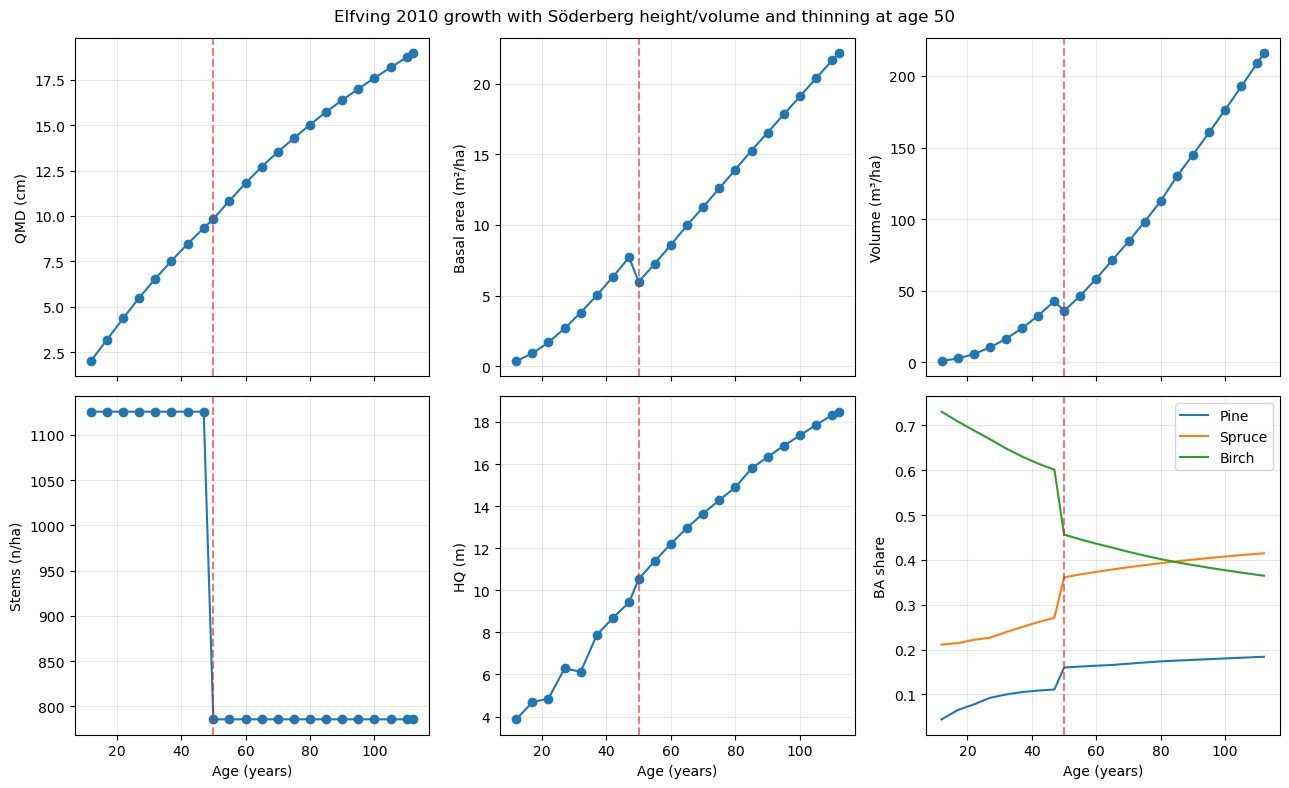

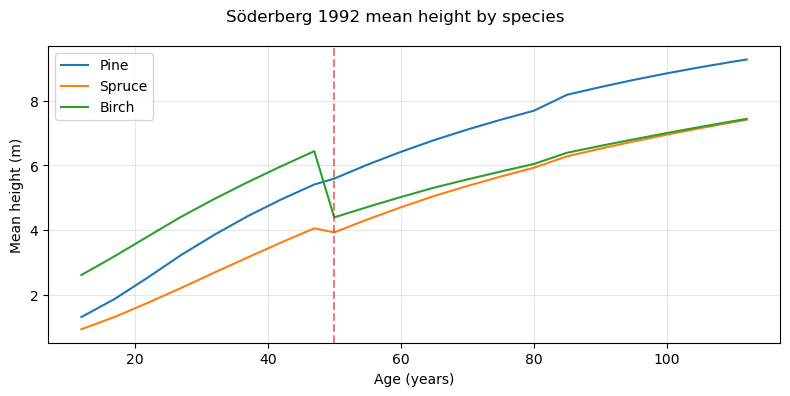

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8), sharex=True)
axes = axes.flatten()

axes[0].plot(results["age_years"], results["qmd_cm"], marker="o")
axes[0].set_ylabel("QMD (cm)")

axes[1].plot(results["age_years"], results["basal_area_m2_ha"], marker="o")
axes[1].set_ylabel("Basal area (m²/ha)")

axes[2].plot(results["age_years"], results["volume_m3_ha"], marker="o")
axes[2].set_ylabel("Volume (m³/ha)")

axes[3].plot(results["age_years"], results["stems_per_ha"], marker="o")
axes[3].set_ylabel("Stems (n/ha)")

axes[4].plot(results["age_years"], results["hq_m"], marker="o")
axes[4].set_ylabel("HQ (m)")

axes[5].plot(results["age_years"], results["pine_share"], label="Pine")
axes[5].plot(results["age_years"], results["spruce_share"], label="Spruce")
axes[5].plot(results["age_years"], results["birch_share"], label="Birch")
axes[5].set_ylabel("BA share")
axes[5].legend(loc="best")

for ax in axes:
    ax.axvline(thin_at_age, color="tab:red", linestyle="--", alpha=0.6)
    ax.grid(True, alpha=0.3)

axes[3].set_xlabel("Age (years)")
axes[4].set_xlabel("Age (years)")
axes[5].set_xlabel("Age (years)")
fig.suptitle(
    "Elfving 2010 growth with Söderberg height/volume and thinning at age 50",
    fontsize=12,
)
fig.tight_layout()


fig2, ax2 = plt.subplots(1, 1, figsize=(8, 4))
ax2.plot(results["age_years"], results["pine_mean_height_m"], label="Pine")
ax2.plot(results["age_years"], results["spruce_mean_height_m"], label="Spruce")
ax2.plot(results["age_years"], results["birch_mean_height_m"], label="Birch")
ax2.set_ylabel("Mean height (m)")
ax2.set_xlabel("Age (years)")
ax2.axvline(thin_at_age, color="tab:red", linestyle="--", alpha=0.6)
ax2.grid(True, alpha=0.3)
ax2.legend(loc="best")
fig2.suptitle("Söderberg 1992 mean height by species", fontsize=12)
fig2.tight_layout()
